In [1]:
import numpy as np
from numpy.typing import NDArray
import cv2 as cv
import matplotlib.pyplot as plt
from utils import plot_two_img

# Конвертация между цветовыми пространствами

In [2]:
def calc_H(R, G, B, i, j):
    M = max(R[i, j], G[i, j], B[i, j])
    m = min(R[i, j], G[i, j], B[i, j])
    C = M - m
    if C == 0:
        return 0.0, M, m, C

    if M == R[i, j]:
        h = ((G[i, j] - B[i, j]) / C) % 6
    elif M == G[i, j]:
        h = (B[i, j] - R[i, j]) / C + 2
    elif M == B[i, j]:
        h = (R[i, j] - G[i, j]) / C + 4
    H = 60 * h
    return H, M, m, C


def rgb2hsl(img: NDArray) -> NDArray:
    hsl_img = np.zeros_like(img, dtype=np.float32)
    R = img[:, :, 0] / 255
    G = img[:, :, 1] / 255
    B = img[:, :, 2] / 255
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            H, M, m, C = calc_H(R, G, B, i, j)
            L = (M + m) / 2
            S = 0 if L == 0 or L == 1 else C / (1 - abs(2 * L - 1))
            hsl_img[i, j, 0] = H / 2
            hsl_img[i, j, 2] = S * 255
            hsl_img[i, j, 1] = L * 255

    hsl_img = hsl_img.clip(0, 255).astype("uint8")
    return hsl_img


def rgb2hsv(img: NDArray) -> NDArray:
    hsv_img = np.zeros_like(img, dtype=np.float32)
    R = img[:, :, 0] / 255
    G = img[:, :, 1] / 255
    B = img[:, :, 2] / 255
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            H, M, m, C = calc_H(R, G, B, i, j)
            V = M
            S = 0 if V == 0 else C / V
            hsv_img[i, j, 0] = H / 2
            hsv_img[i, j, 1] = S * 255
            hsv_img[i, j, 2] = V * 255

    hsv_img = hsv_img.clip(0, 255).astype("uint8")
    return hsv_img

# HSV

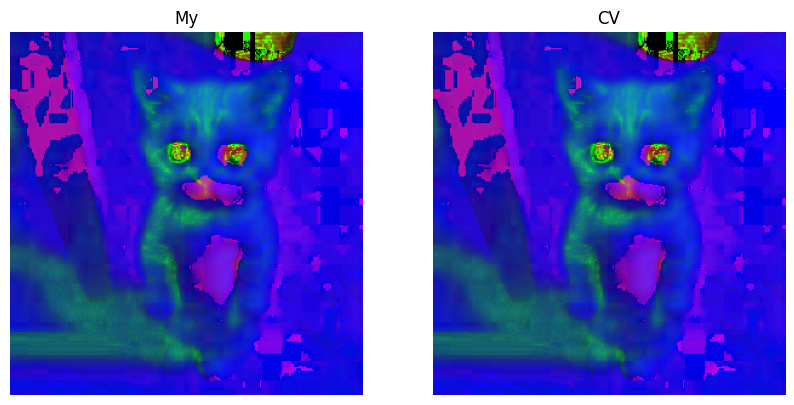

In [3]:
img = cv.imread('cat.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
hsv_img = cv.cvtColor(img, cv.COLOR_RGB2HSV)
my_hsv_img = rgb2hsv(img)

plot_two_img(my_hsv_img, hsv_img)

# HLS

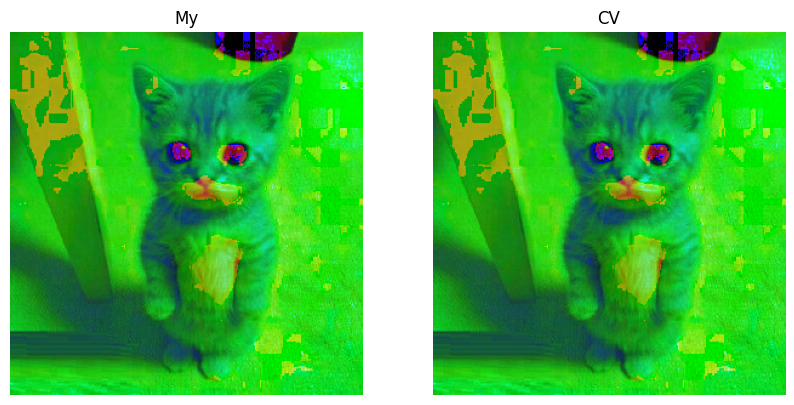

In [4]:
img = cv.imread('cat.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
hsl_img = cv.cvtColor(img, cv.COLOR_RGB2HLS)
my_hsl_img = rgb2hsl(img)

plot_two_img(my_hsl_img, hsl_img)

# Blending

In [5]:
def my_blending(img1: NDArray, alpha: float, img2: NDArray, beta: float, gamma: float) -> NDArray:
    new_img = img1 * alpha + img2 * beta + gamma
    return new_img.clip(0, 255).astype("uint8")

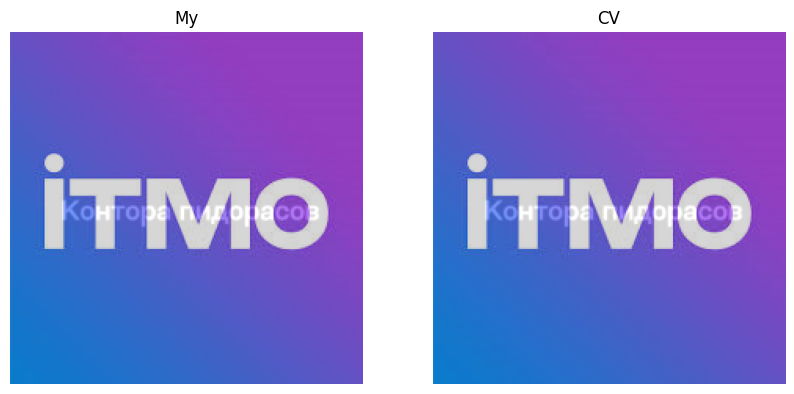

In [6]:
itmo = cv.imread('itmo.png', cv.IMREAD_COLOR_RGB)
kontora = cv.imread('kontora.png', cv.IMREAD_COLOR_RGB)
kontora = cv.resize(kontora, (225, 225))
my_blend = my_blending(itmo, 0.8, kontora, 0.2, 10.0)
blend = cv.addWeighted(itmo, 0.8, kontora, 0.2, 10.0)

plot_two_img(my_blend, blend)

# Пороговая обработка

In [14]:
def binary(img: NDArray, threshold: int, max_val: int) -> NDArray:
    return np.where(img >= threshold, max_val, 0)


def binary_inv(img: NDArray, threshold: int, max_val: int) -> NDArray:
    return np.where(img >= threshold, 0, max_val)


def to_zero(img: NDArray, threshold: int) -> NDArray:
    return np.where(img >= threshold, img, 0)


def to_zero_inv(img: NDArray, threshold: int) -> NDArray:
    return np.where(img >= threshold, 0, img)


def truncate(img: NDArray, threshold: int) -> NDArray:
    return np.where(img >= threshold, threshold, img)


def

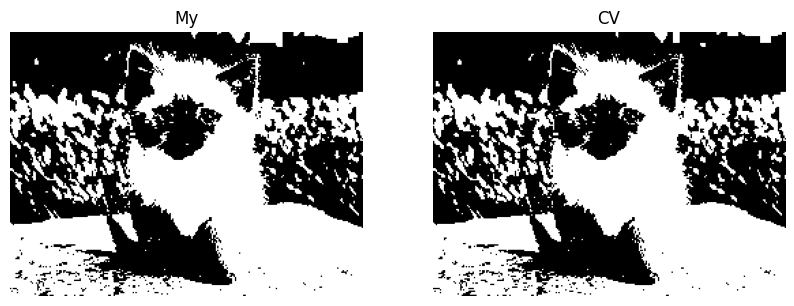

In [10]:
cat = cv.imread('cat2.png', cv.IMREAD_GRAYSCALE)
my_bin_cat = binary(cat, 127, 255)
ret, bin_cat = cv.threshold(cat, 127, 255, cv.THRESH_BINARY)
plot_two_img(my_bin_cat, bin_cat, cmap='gray')

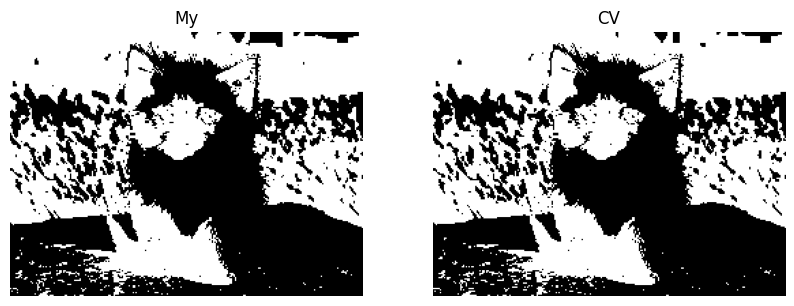

In [11]:
my_int_bin_cat = binary_inv(cat, 127, 255)
ret, bin_inv_cat = cv.threshold(cat, 127, 255, cv.THRESH_BINARY_INV)
plot_two_img(my_int_bin_cat, bin_inv_cat, cmap='gray')

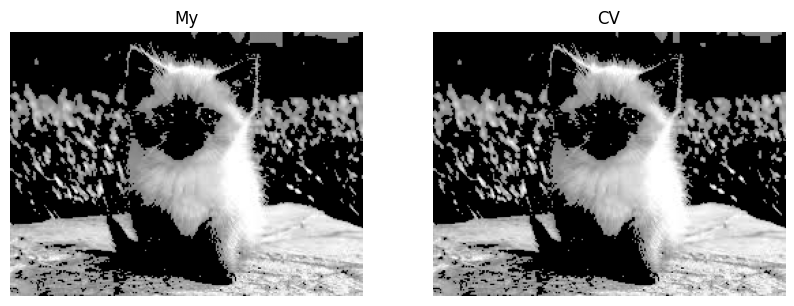

In [12]:
my_to_zero_cat = to_zero(cat, 127)
ret, to_zero_cat = cv.threshold(cat, 127, 255, cv.THRESH_TOZERO)
plot_two_img(my_to_zero_cat, to_zero_cat, cmap='gray')

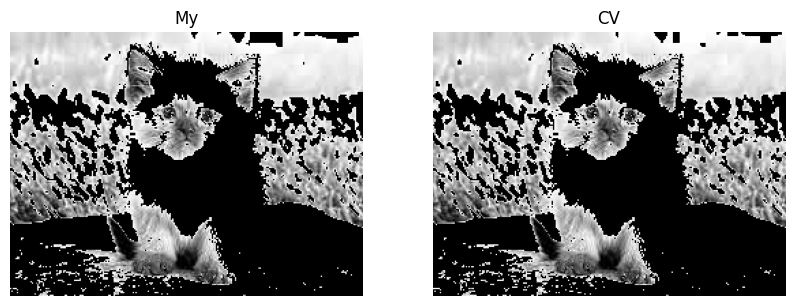

In [13]:
my_to_zero_inv_cat = to_zero_inv(cat, 127)
ret, to_zero_inv_cat = cv.threshold(cat, 127, 255, cv.THRESH_TOZERO_INV)
plot_two_img(my_to_zero_inv_cat, to_zero_inv_cat, cmap='gray')

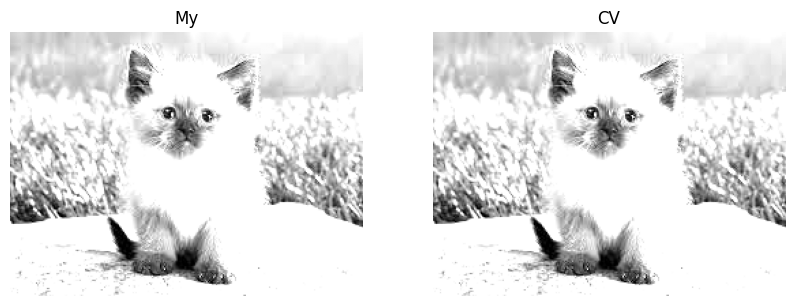

In [15]:
my_truncate_cat = truncate(cat, 127)
ret, truncate_cat = cv.threshold(cat, 127, 255, cv.THRESH_TRUNC)
plot_two_img(my_truncate_cat, truncate_cat, cmap='gray')